## 1. Install Libraries

In [37]:
!pip install -q umap-learn

!pip install -q hdbscan

!pip install -q joblib

## 2. Imports

In [38]:
import os
import gc
import time
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import umap
import hdbscan

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

## 3. Project Paths

In [39]:
PROJECT_PATH = "/content/drive/MyDrive/FinSight_AI"

DATA_PATH = os.path.join(
    PROJECT_PATH,
    "data"
)

EMBEDDING_PATH = os.path.join(
    DATA_PATH,
    "embeddings"
)

EMBEDDING_BATCH_PATH = os.path.join(
    EMBEDDING_PATH,
    "embedding_batches"
)

PROCESSED_PATH = os.path.join(
    DATA_PATH,
    "processed"
)

CLUSTER_PATH = os.path.join(
    DATA_PATH,
    "clusters"
)

MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "models"
)

REPORT_PATH = os.path.join(
    PROJECT_PATH,
    "reports"
)

os.makedirs(CLUSTER_PATH, exist_ok=True)

os.makedirs(MODEL_PATH, exist_ok=True)

os.makedirs(REPORT_PATH, exist_ok=True)

## 4. Load Manifest

In [40]:
manifest_df = pd.read_parquet(

    os.path.join(

        EMBEDDING_PATH,

        "embedding_manifest.parquet"

    )

)

manifest_df.head()

,batch_number,start_row,end_row,rows,embedding_dimension,embedding_file,metadata_file
0,1,0,4999,5000,768,embedding_batch_0001.npy,metadata_batch_0001.parquet
1,2,5000,9999,5000,768,embedding_batch_0002.npy,metadata_batch_0002.parquet
2,3,10000,14999,5000,768,embedding_batch_0003.npy,metadata_batch_0003.parquet
3,4,15000,19999,5000,768,embedding_batch_0004.npy,metadata_batch_0004.parquet
4,5,20000,24999,5000,768,embedding_batch_0005.npy,metadata_batch_0005.parquet


## 5. Dataset Information

In [41]:
TOTAL_BATCHES = len(manifest_df)

TOTAL_ROWS = manifest_df["rows"].sum()

print(

    "Total Batches :",

    TOTAL_BATCHES

)

print(

    "Total Headlines :",

    f"{TOTAL_ROWS:,}"

)

Total Batches : 644
Total Headlines : 3,215,296


## 6. Clustering Configuration

In [42]:
SAMPLE_SIZE = 200000

RANDOM_STATE = 42

EMBEDDING_DIM = 768

print(

    "Sample Size :",

    f"{SAMPLE_SIZE:,}"

)

Sample Size : 200,000


## 7. Load Sample Embeddings

In [43]:
sample_embeddings = []

sample_metadata = []

rows_loaded = 0

for _, row in tqdm(

    manifest_df.iterrows(),

    total=len(manifest_df),

    desc="Loading Sample"

):

    embedding_file = os.path.join(

        EMBEDDING_BATCH_PATH,

        row["embedding_file"]

    )

    metadata_file = os.path.join(

        EMBEDDING_BATCH_PATH,

        row["metadata_file"]

    )

    embeddings = np.load(

        embedding_file,

        mmap_mode="r"

    )

    metadata = pd.read_parquet(

        metadata_file

    )

    remaining = SAMPLE_SIZE - rows_loaded

    if remaining <= 0:

        break

    take = min(

        remaining,

        len(embeddings)

    )

    sample_embeddings.append(

        embeddings[:take]

    )

    sample_metadata.append(

        metadata.iloc[:take]

    )

    rows_loaded += take

embeddings = np.vstack(

    sample_embeddings

).astype(np.float32)

metadata = pd.concat(

    sample_metadata,

    ignore_index=True

)

print(

    "Embeddings Shape :",

    embeddings.shape

)

print(

    "Metadata Shape :",

    metadata.shape
)

Loading Sample:   0%|          | 0/644 [00:00<?, ?it/s]

Embeddings Shape : (200000, 768)
Metadata Shape : (200000, 4)


## 8. Quick Memory Check

In [44]:
print(

    f"Embedding Size : {embeddings.nbytes / 1024**2:.2f} MB"

)

metadata.info()

Embedding Size : 585.94 MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 4 columns):
 #   Column          Non-Null Count   Dtype              
---  ------          --------------   -----              
 0   news_id         200000 non-null  int64              
 1   ticker          200000 non-null  category           
 2   published_date  200000 non-null  datetime64[ns, UTC]
 3   source          200000 non-null  category           
dtypes: category(2), datetime64[ns, UTC](1), int64(1)
memory usage: 3.9 MB


## 9. Verify Sample

In [45]:
metadata.head()

,news_id,ticker,published_date,source
0,1,A,2020-06-05 14:30:54+00:00,analyst
1,2,A,2020-06-03 14:45:20+00:00,analyst
2,3,A,2020-05-26 08:30:07+00:00,analyst
3,4,A,2020-05-22 16:45:06+00:00,analyst
4,5,A,2020-05-22 15:38:59+00:00,analyst


## 10. UMAP Dimensionality Reduction

In [35]:
import time

UMAP_COMPONENTS = 10

umap_model = umap.UMAP(

    n_neighbors=15,

    n_components=10,

    min_dist=0.05,

    metric="cosine",

    random_state=42,

    low_memory=True,

    verbose=True

)

print("=" * 70)
print("Starting UMAP Dimensionality Reduction")
print("=" * 70)

print(f"Input Shape      : {embeddings.shape}")
print(f"Output Dimension : {UMAP_COMPONENTS}")
print(f"Neighbors        : 50")
print(f"Metric           : cosine")
print(f"Low Memory Mode  : True")
print()

start = time.time()

reduced_embeddings = umap_model.fit_transform(
    embeddings
)

elapsed = time.time() - start

print()
print("=" * 70)
print("UMAP COMPLETED")
print("=" * 70)

print(f"Output Shape     : {reduced_embeddings.shape}")
print(f"Total Time       : {elapsed/60:.2f} minutes")
print(f"Original Dim     : {embeddings.shape[1]}")
print(f"Reduced Dim      : {reduced_embeddings.shape[1]}")

Starting UMAP Dimensionality Reduction
Input Shape      : (200000, 768)
Output Dimension : 10
Neighbors        : 50
Metric           : cosine
Low Memory Mode  : True

UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.05, n_components=10, n_jobs=1, random_state=42, verbose=True)
Sat Jul  4 07:05:27 2026 Construct fuzzy simplicial set
Sat Jul  4 07:05:28 2026 Finding Nearest Neighbors
Sat Jul  4 07:05:28 2026 Building RP forest with 27 trees
Sat Jul  4 07:06:08 2026 NN descent for 18 iterations
	 1  /  18
	 2  /  18
	 3  /  18
	 4  /  18
	 5  /  18
	Stopping threshold met -- exiting after 5 iterations
Sat Jul  4 07:07:22 2026 Finished Nearest Neighbor Search
Sat Jul  4 07:07:30 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Sat Jul  4 10:36:14 2026 Finished embedding

UMAP COMPLETED
Output Shape     : (200000, 10)
Total Time       : 210.82 minutes
Original Dim     : 768
Reduced Dim      : 10
Starting UMAP Dimensionality Reduction
Input Shape      : (200000, 768)
Output Dimension : 10
Neighbors        : 50
Metric           : cosine
Low Memory Mode  : True

UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.05, n_components=10, n_jobs=1, random_state=42, verbose=True)
Sat Jul  4 11:34:27 2026 Construct fuzzy simplicial set
Sat Jul  4 11:34:28 2026 Finding Nearest Neighbors
Sat Jul  4 11:34:28 2026 Building RP forest with 27 trees
Sat Jul  4 11:35:31 2026 NN descent for 18 iterations
	 1  /  18
	 2  /  1

KeyboardInterrupt: 

## 11. Save the UMAP Model

In [ ]:
joblib.dump(

    umap_model,

    os.path.join(

        MODEL_PATH,

        "umap_model.pkl"

    )

)

print("UMAP model saved successfully.")

Sat Jul  4 10:36:54 2026 Building hub-based search tree
Sat Jul  4 10:37:16 2026 Forward diversification reduced edges from 3000000 to 1297392
Sat Jul  4 10:37:23 2026 Reverse diversification reduced edges from 1297392 to 1297392
Sat Jul  4 10:37:28 2026 Degree pruning reduced edges from 1467754 to 1466132
Sat Jul  4 10:37:28 2026 Resorting data and graph based on tree order
Sat Jul  4 10:37:28 2026 Building and compiling search function
UMAP model saved successfully.


## 12. Save Reduced Embeddings

In [ ]:
np.save(

    os.path.join(

        CLUSTER_PATH,

        "sample_reduced_embeddings.npy"

    ),

    reduced_embeddings

)

print("Reduced embeddings saved.")

Reduced embeddings saved.


## 11. HDBSCAN

In [57]:
import time

print("=" * 70)
print("Starting HDBSCAN Clustering")
print("=" * 70)

clusterer = hdbscan.HDBSCAN(

    min_cluster_size=20,

    min_samples=5,

    metric="euclidean",

    cluster_selection_method="eom",

    prediction_data=True,

    core_dist_n_jobs=-1

)

start = time.time()

cluster_labels = clusterer.fit_predict(
    reduced_embeddings
)

elapsed = time.time() - start

print()

print("=" * 70)
print("HDBSCAN COMPLETED")
print("=" * 70)

print(f"Total Time : {elapsed/60:.2f} minutes")
print(f"Total Labels : {len(cluster_labels):,}")

Starting HDBSCAN Clustering

HDBSCAN COMPLETED
Total Time : 2.26 minutes
Total Labels : 200,000


In [ ]:
import time

results = []

configs = [

    (50, 20),

    (40, 15),

    (30, 10),

    (25, 8),

    (20, 5)

]

metrics = [

    "euclidean",

    "manhattan",

    "l2"

]

selection_methods = [

    "eom",

    "leaf"

]

TOTAL_RUNS = len(configs) * len(metrics) * len(selection_methods)

run = 1

overall_start = time.time()

for metric in metrics:

    for method in selection_methods:

        for min_cluster_size, min_samples in configs:

            print("="*80)

            print(f"Run {run}/{TOTAL_RUNS}")

            print(f"Metric               : {metric}")

            print(f"Selection Method     : {method}")

            print(f"min_cluster_size     : {min_cluster_size}")

            print(f"min_samples          : {min_samples}")

            start = time.time()

            clusterer = hdbscan.HDBSCAN(

                min_cluster_size=min_cluster_size,

                min_samples=min_samples,

                metric=metric,

                cluster_selection_method=method,

                prediction_data=True,

                core_dist_n_jobs=-1

            )

            labels = clusterer.fit_predict(

                reduced_embeddings

            )

            noise = (labels == -1).sum()

            clusters = len(set(labels))

            if -1 in labels:

                clusters -= 1

            largest_cluster = (

                pd.Series(labels)

                .value_counts()

                .drop(

                    labels=[-1],

                    errors="ignore"

                )

                .max()

            )

            elapsed = time.time() - start

            results.append({

                "metric": metric,

                "cluster_selection": method,

                "min_cluster_size": min_cluster_size,

                "min_samples": min_samples,

                "clusters": clusters,

                "noise_points": noise,

                "noise_percent": round(

                    100 * noise / len(labels),

                    2

                ),

                "largest_cluster": largest_cluster,

                "time_minutes": round(

                    elapsed / 60,

                    2

                )

            })

            run += 1

results_df = (

    pd.DataFrame(results)

    .sort_values(

        by=[

            "noise_percent",

            "clusters"

        ]

    )

    .reset_index(drop=True)

)

print()

print("="*80)

print("ALL EXPERIMENTS COMPLETED")

print(f"Total Time : {(time.time()-overall_start)/60:.2f} minutes")

results_df

Run 1/30
Metric               : euclidean
Selection Method     : eom
min_cluster_size     : 50
min_samples          : 20
Run 2/30
Metric               : euclidean
Selection Method     : eom
min_cluster_size     : 40
min_samples          : 15
Run 3/30
Metric               : euclidean
Selection Method     : eom
min_cluster_size     : 30
min_samples          : 10
Run 4/30
Metric               : euclidean
Selection Method     : eom
min_cluster_size     : 25
min_samples          : 8
Run 5/30
Metric               : euclidean
Selection Method     : eom
min_cluster_size     : 20
min_samples          : 5
Run 6/30
Metric               : euclidean
Selection Method     : leaf
min_cluster_size     : 50
min_samples          : 20
Run 7/30
Metric               : euclidean
Selection Method     : leaf
min_cluster_size     : 40
min_samples          : 15
Run 8/30
Metric               : euclidean
Selection Method     : leaf
min_cluster_size     : 30
min_samples          : 10
Run 9/30
Metric               :

,metric,cluster_selection,min_cluster_size,min_samples,clusters,noise_points,noise_percent,largest_cluster,time_minutes
0,euclidean,eom,20,5,2823,46893,23.45,3491,1.17
1,l2,eom,20,5,2823,46893,23.45,3491,1.14
2,manhattan,eom,20,5,2817,46939,23.47,3505,1.65
3,euclidean,eom,25,8,2205,49176,24.59,3505,1.56
4,l2,eom,25,8,2205,49176,24.59,3505,1.39
5,manhattan,eom,25,8,2213,50570,25.28,3505,1.97
6,euclidean,eom,30,10,1823,50825,25.41,3505,1.49
7,l2,eom,30,10,1823,50825,25.41,3505,1.52
8,manhattan,eom,30,10,1818,52382,26.19,3505,2.10
9,euclidean,eom,40,15,1304,56356,28.18,3505,1.62


In [ ]:
results_df["score"] = (

    results_df["noise_percent"]

    +

    abs(results_df["clusters"] - 900) / 40

)

results_df.sort_values("score").head(10)

,metric,cluster_selection,min_cluster_size,min_samples,clusters,noise_points,noise_percent,largest_cluster,time_minutes,score
12,manhattan,eom,50,20,946,60033,30.02,3505,2.63,31.170
13,euclidean,eom,50,20,976,61766,30.88,3505,1.79,32.780
14,l2,eom,50,20,976,61766,30.88,3505,1.76,32.780
9,euclidean,eom,40,15,1304,56356,28.18,3505,1.62,38.280
10,l2,eom,40,15,1304,56356,28.18,3505,1.60,38.280
11,manhattan,eom,40,15,1290,57595,28.80,3505,2.38,38.550
27,euclidean,leaf,50,20,1087,78452,39.23,838,1.74,43.905
28,l2,leaf,50,20,1087,78452,39.23,838,1.72,43.905
29,manhattan,leaf,50,20,1065,79562,39.78,838,2.59,43.905
6,euclidean,eom,30,10,1823,50825,25.41,3505,1.49,48.485


## 12. Add Cluster Labels

In [58]:
metadata["cluster"] = cluster_labels

metadata.head()

,news_id,ticker,published_date,source,cluster
0,1,A,2020-06-05 14:30:54+00:00,analyst,17
1,2,A,2020-06-03 14:45:20+00:00,analyst,702
2,3,A,2020-05-26 08:30:07+00:00,analyst,406
3,4,A,2020-05-22 16:45:06+00:00,analyst,537
4,5,A,2020-05-22 15:38:59+00:00,analyst,-1


## 13. Cluster Statistics

In [59]:
cluster_stats = (

    metadata

    .groupby("cluster")

    .size()

    .reset_index(name="count")

    .sort_values(

        "count",

        ascending=False

    )

    .reset_index(drop=True)

)

cluster_stats.head(20)

,cluster,count
0,-1,46893
1,980,3491
2,2155,1563
3,1081,924
4,1064,785
5,2127,766
6,499,757
7,318,713
8,2040,653
9,2821,643


## 14. Summary Statistics

In [60]:
num_clusters = (

    cluster_stats["cluster"] != -1

).sum()

noise_points = (

    cluster_labels == -1

).sum()

summary = pd.DataFrame({

    "Metric":[

        "Sample Size",

        "Clusters Found",

        "Noise Points",

        "Noise Percentage"

    ],

    "Value":[

        len(cluster_labels),

        num_clusters,

        noise_points,

        round(

            noise_points /

            len(cluster_labels)

            *100,

            2

        )

    ]

})

summary

,Metric,Value
0,Sample Size,200000.00
1,Clusters Found,2823.00
2,Noise Points,46893.00
3,Noise Percentage,23.45


## 15. Cluster Size Distribution

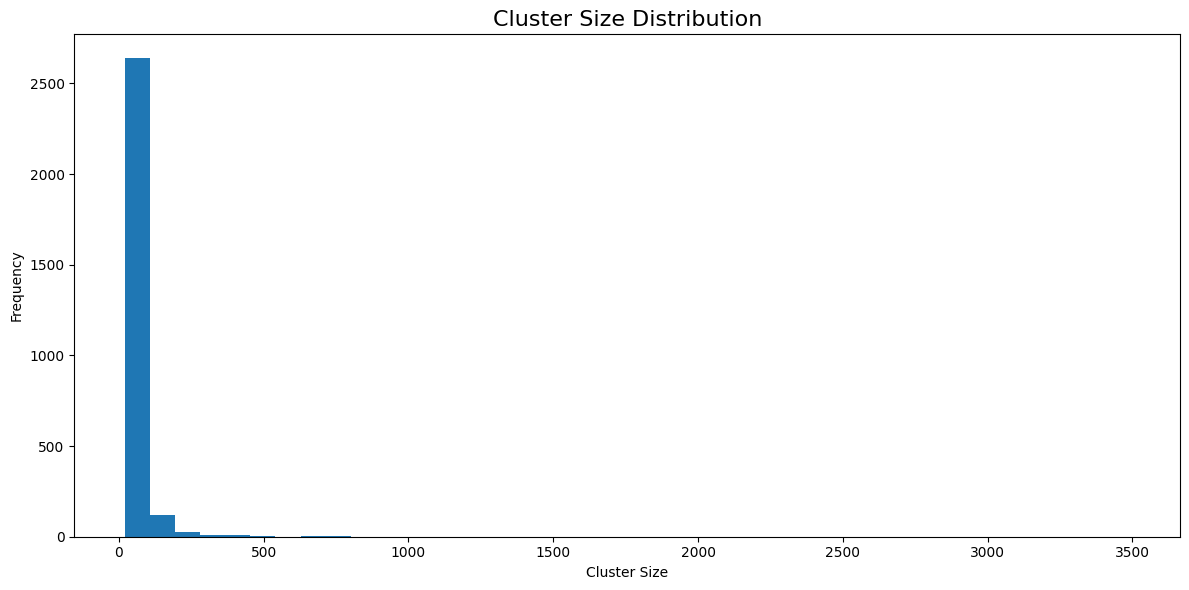

In [61]:
plt.figure(figsize=(12,6))

plt.hist(

    cluster_stats.loc[

        cluster_stats["cluster"] != -1,

        "count"

    ],

    bins=40

)

plt.title(

    "Cluster Size Distribution",

    fontsize=16

)

plt.xlabel("Cluster Size")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

## 16. Save the Models

In [62]:
joblib.dump(

    umap_model,

    os.path.join(

        MODEL_PATH,

        "umap_model.pkl"

    )

)

joblib.dump(

    clusterer,

    os.path.join(

        MODEL_PATH,

        "hdbscan_model.pkl"

    )

)

print("Models saved successfully.")

Models saved successfully.


## 17. Save the Reduced Embeddings

In [63]:
np.save(

    os.path.join(

        CLUSTER_PATH,

        "sample_reduced_embeddings.npy"

    ),

    reduced_embeddings

)

print("Reduced embeddings saved.")

Reduced embeddings saved.


## 18. Save Cluster Assignments

In [64]:
metadata.to_parquet(

    os.path.join(

        CLUSTER_PATH,

        "sample_cluster_labels.parquet"

    ),

    index=False

)

print("Cluster assignments saved.")

Cluster assignments saved.


## 19. Save Cluster Statistics

In [65]:
cluster_stats.to_parquet(

    os.path.join(

        REPORT_PATH,

        "cluster_statistics.parquet"

    ),

    index=False

)

summary.to_parquet(

    os.path.join(

        REPORT_PATH,

        "cluster_summary.parquet"

    ),

    index=False

)

print("Cluster reports saved.")

Cluster reports saved.


## 20. Inspect the Largest Clusters

In [66]:
top_clusters = (

    cluster_stats

    .query("cluster != -1")

    .head(10)

)

top_clusters

,cluster,count
1,980,3491
2,2155,1563
3,1081,924
4,1064,785
5,2127,766
6,499,757
7,318,713
8,2040,653
9,2821,643
10,1745,629


## 21. View Example Headlines from a Cluster

In [67]:
financial_news = pd.read_parquet(

    os.path.join(

        PROCESSED_PATH,

        "financial_news_clean.parquet"

    ),

    columns=[

        "news_id",

        "headline"

    ]

)

cluster_id = top_clusters.iloc[0]["cluster"]

examples = (

    metadata

    .query("cluster == @cluster_id")

    .merge(

        financial_news,

        on="news_id"

    )

)

examples[["headline"]].head(20)

,headline
0,Mid-Morning Market Update: Markets Open Lower;...
1,"Mid-Day Market Update: SunEdison, TerraForm Ju..."
2,Mid-Morning Market Update: Markets Gain; Home ...
3,Mid-Afternoon Market Update: Cray Shows Streng...
4,Mid-Day Market Update: Agilent Shares Rise On ...
5,Mid-Morning Market Update: Markets Rise; Nords...
6,Mid-Day Market Update: Rite Aid Surges On Surp...
7,Mid-Morning Market Update: Markets Edge Lower;...
8,"Sprint Ticking Higher, Retracing Most of its E..."
9,Dendreon Plunging After Hours (DNDN)


In [68]:
valid_clusters = metadata[metadata["cluster"] != -1]

cluster_sizes = (
    valid_clusters["cluster"]
    .value_counts()
)

print(cluster_sizes.describe())

count    2823.000000
mean       54.235565
std        93.034100
min        20.000000
25%        27.000000
50%        37.000000
75%        56.000000
max      3491.000000
Name: count, dtype: float64


In [69]:
largest_cluster = cluster_stats.iloc[0]["cluster"]

print(largest_cluster)

-1


In [70]:
examples = (

    metadata

    .query("cluster == @largest_cluster")

    .merge(

        financial_news,

        on="news_id"

    )

)

examples["headline"].head(50)

,headline
0,B of A Securities Maintains Neutral on Agilent...
1,Agilent Technologies shares are trading higher...
2,Agilent Technologies shares are trading higher...
3,Agilent Technologies Receives FDA Approval for...
4,Agilent Reports FDA Approval For PD-L1 Compani...
5,Agilent Withdraws Q2 And FY20 Guidance
6,Shares of several companies in the auto dealer...
7,Int'l. Air Transport Authority Chief Economist...
8,Barclays Maintains Equal-Weight on Agilent Tec...
9,Citigroup Maintains Neutral on Agilent Technol...


In [71]:
largest_cluster = (

    metadata[metadata["cluster"] != -1]["cluster"]

    .value_counts()

    .idxmax()

)

print(largest_cluster)

980


In [72]:
examples = (

    metadata

    .query("cluster == @largest_cluster")

    .merge(

        financial_news,

        on="news_id"

    )

)

examples["headline"].head(50)

,headline
0,Mid-Morning Market Update: Markets Open Lower;...
1,"Mid-Day Market Update: SunEdison, TerraForm Ju..."
2,Mid-Morning Market Update: Markets Gain; Home ...
3,Mid-Afternoon Market Update: Cray Shows Streng...
4,Mid-Day Market Update: Agilent Shares Rise On ...
5,Mid-Morning Market Update: Markets Rise; Nords...
6,Mid-Day Market Update: Rite Aid Surges On Surp...
7,Mid-Morning Market Update: Markets Edge Lower;...
8,"Sprint Ticking Higher, Retracing Most of its E..."
9,Dendreon Plunging After Hours (DNDN)
